In [1]:
# Install necessary libraries
!pip install -q transformers #torch torchvision matplotlib opencv-python

ERROR: Invalid requirement: '#torch'
You should consider upgrading via the 'C:\fidle-tp\fidle-env\Scripts\python.exe -m pip install --upgrade pip' command.


In [1]:
# Import libraries
import torch
from transformers import DetrImageProcessor, DetrForObjectDetection
from torchvision.transforms import functional as F
import requests
from PIL import Image
import matplotlib.pyplot as plt
import cv2



In [4]:
# Load pre-trained DETR model from Hugging Face Hub
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50")




/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.59k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [5]:
# Function to perform pose detection and visualize results
def detect_and_visualize(image_path, model, processor):
    # Load and preprocess the image
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt")

    # Perform inference
    outputs = model(**inputs)

    # Get predicted bounding boxes and labels
    target_sizes = torch.tensor([image.size])
    results = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=0.9)[0]

    # Draw results on the image
    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
        box = [int(i) for i in box.tolist()]
        cv2.rectangle(img, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 2)
        cv2.putText(img, f"{model.config.id2label[label.item()]}: {round(score.item(), 3)}",
                    (box[0], box[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    # Show the image with bounding boxes
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis("off")
    plt.show()



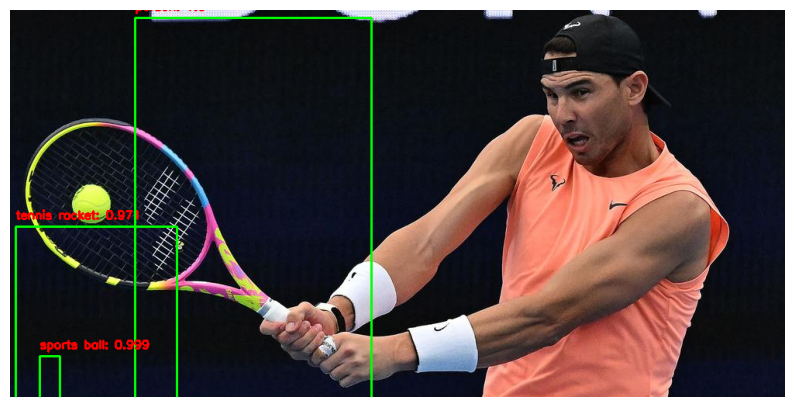

In [8]:
# Example usage with a sample image
#image_url = "https://example.com/sample.jpg"  # Replace with an actual image URL
image_path = "/content/sample_data/nadal.jpg"
#response = requests.get(image_url)

# The following line was attempting to write the string 'image_path' to the file,
# instead of the actual image data. This has been removed.
#with open(image_path, "wb") as f:
#    f.write(image_path)

# Detect and visualize directly using the image_path
detect_and_visualize(image_path, model, processor)

# For multiple images, loop over the image paths
# image_paths = ["image1.jpg", "image2.jpg", ..., "image10.jpg"]
# for img_path in image_paths:
#     detect_and_visualize(img_path, model, processor)

# YOLO Bounding Box

In [33]:
# Install necessary libraries
!pip install -q ultralytics torch torchvision matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 886.3/886.3 kB 13.1 MB/s eta 0:00:00


In [34]:
# Import libraries
import torch
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
import requests
from PIL import Image

# Step 1: Load a pre-trained YOLO model
# We use YOLOv8 in this example
model = YOLO('yolov8n.pt')  # Use a pre-trained YOLOv8 model


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 6.25M/6.25M [00:00<00:00, 57.6MB/s]


In [ ]:
# Step 2: Inference with the pre-trained model
# Load an image
#image_url = "/content/sample_data/nadal.jpg"  # Replace with an actual image URL
image_path = "C:\Users\Kered\ML_DVRC_2025\Lecture8\CNN\Lab2\nadal.jpg"
# response = requests.get(image_url)
# with open(image_path, "wb") as f:
#     f.write(response.content)

# Perform inference
results = model(image_path)


image 1/1 /content/sample_data/nadal.jpg: 320x640 1 person, 1 sports ball, 2 tennis rackets, 365.0ms
Speed: 30.1ms preprocess, 365.0ms inference, 36.1ms postprocess per image at shape (1, 3, 320, 640)


In [41]:
# Step 3: Visualize results
def visualize_results(image_path, results):
    # Load the original image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Draw bounding boxes
    if results[0].boxes is not None:
        for box in results[0].boxes:  # Each box contains xyxy, confidence, and class
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            conf = box.conf[0].item()
            cls = int(box.cls[0].item())
            label = f"{model.names[cls]} {conf:.2f}"
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    # Display the image
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis("off")
    plt.show()




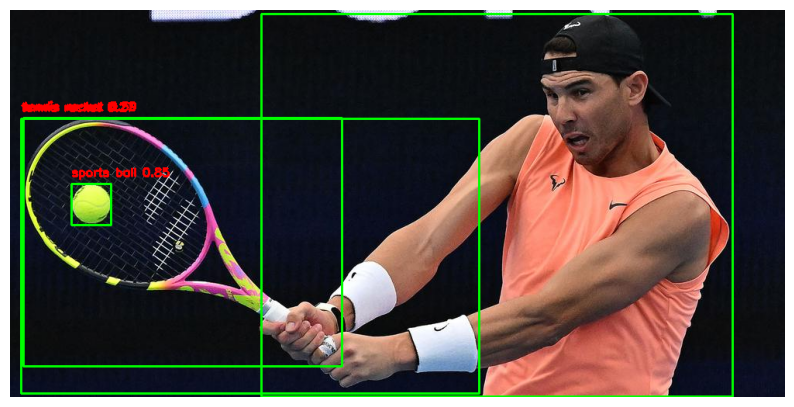

In [42]:
# Visualize the inference results
# Visualize the inference results
visualize_results(image_path, results)

# Tokenizer Human_Pose
* https://huggingface.co/EPFL-VILAB/4M_tokenizers_human-poses_1k_8

* Try to run a better Tokenizer for Human pose